### Connect to `coffee_db` via `src.load.get_engine()`

This now reuses the project's own ETL connection helper (`src/load.py`) instead of a
hardcoded/duplicated connection string, so the notebook always talks to whatever
Postgres the pipeline itself loaded (`coffee_db` in pgAdmin4, per `.env`).

In [19]:
import sys
from pathlib import Path

# notebooks/ sits one level below the project root -> add project root to sys.path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import inspect
from src.load import get_engine

plt.style.use('default')

engine = get_engine()

insp = inspect(engine)
tables = insp.get_table_names()
print("Connected via src.load.get_engine()")
print("Tables found:", tables)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

Connected via src.load.get_engine()
Tables found: ['coffee_import', 'coffee_re_export', 'coffee_production', 'coffee_domestic_consumption', 'coffee_export', 'coffee_importers_consumption', 'global_co2']


### Helper: wide (year-columns) -> long (tidy) format
All the coffee tables store 1990-2019 as individual columns (e.g. `1990`, `1991`, ...).
This helper melts them into a tidy `country, country_code, year, value` frame, which is
what we need for time-series analysis and most plotting.

In [20]:
YEAR_COLS = [str(y) for y in range(1990, 2020)]

def melt_years(df, value_name, id_vars=("country_code", "country")):
    """Convert a wide year-columns dataframe into tidy long format."""
    id_vars = [c for c in id_vars if c in df.columns]
    year_cols = [c for c in YEAR_COLS if c in df.columns]
    long_df = df.melt(id_vars=id_vars, value_vars=year_cols,
                       var_name="year", value_name=value_name)
    long_df["year"] = long_df["year"].astype(int)
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df

### Load raw tables from Postgres
Table names come straight from `config.yaml` / `src/load.py`:
`coffee_production`, `coffee_domestic_consumption`, `coffee_import`,
`coffee_export`, `coffee_re_export`, `coffee_importers_consumption`, `global_co2`.

In [21]:
df_production            = pd.read_sql("SELECT * FROM coffee_production", engine)
df_domestic_consumption  = pd.read_sql("SELECT * FROM coffee_domestic_consumption", engine)
df_import                = pd.read_sql("SELECT * FROM coffee_import", engine)
df_export                = pd.read_sql("SELECT * FROM coffee_export", engine)
df_re_export             = pd.read_sql("SELECT * FROM coffee_re_export", engine)
df_importers_consumption = pd.read_sql("SELECT * FROM coffee_importers_consumption", engine)

for name, df in [
    ("production", df_production),
    ("domestic_consumption", df_domestic_consumption),
    ("import", df_import),
    ("export", df_export),
    ("re_export", df_re_export),
    ("importers_consumption", df_importers_consumption),
]:
    print(f"{name:>22}: {df.shape[0]:>4} rows, {df.shape[1]:>3} cols")

            production:   55 rows,  34 cols
  domestic_consumption:   55 rows,  34 cols
                import:   34 rows,  33 cols
                export:   55 rows,  33 cols
             re_export:   34 rows,  33 cols
 importers_consumption:   34 rows,  33 cols


### Qn — Producing vs. Non-producing countries: consumption/re-export balance over time

Two categories, built directly from which table each country appears in:

| Category | Consumption source | Re-export source |
|---|---|---|
| **Coffee-producing** | `coffee_domestic_consumption` | `coffee_re_export` (0 for these countries — the dataset has no re-export rows for producers) |
| **Non-producing** | `coffee_importers_consumption` | `coffee_re_export` |

`balance = consumption - re_export`. For producing countries this collapses to
their domestic consumption (no re-export activity in the data); for non-producing
countries it nets out how much of what they import gets re-exported onward
(e.g. EU distribution hubs) versus consumed locally.

In [22]:
producing_codes = set(df_production["country_code"].dropna().unique())

# consumption, tagged by category, unioned from the two mutually-exclusive tables
cons_prod = melt_years(df_domestic_consumption, "consumption")
cons_prod["category"] = "Coffee-producing"

cons_nonprod = melt_years(df_importers_consumption, "consumption")
cons_nonprod["category"] = "Non-producing"

consumption_long = pd.concat([cons_prod, cons_nonprod], ignore_index=True)

# re-export only has rows for non-producing countries in this dataset;
# producing countries are still included with re_export = 0 so both categories
# are represented every year
re_export_long = melt_years(df_re_export, "re_export")
re_export_long["category"] = "Non-producing"

balance_df = pd.merge(
    consumption_long, re_export_long,
    on=["country_code", "country", "year", "category"],
    how="left"
)
balance_df["re_export"] = balance_df["re_export"].fillna(0)
balance_df["balance"] = balance_df["consumption"] - balance_df["re_export"]

assert set(balance_df.loc[balance_df["country_code"].isin(producing_codes), "category"]) <= {"Coffee-producing"}
balance_df.groupby("category")[["consumption", "re_export", "balance"]].sum() / 1e6

,consumption,re_export,balance
category,,,
Coffee-producing,61186.765103,0.00,61186.765103
Non-producing,131354.940000,45667.44,85687.500000


### Full time series (all years, not just samples)

Same balance metric, plotted continuously per category rather than sampled, for
a complete year-over-year picture.

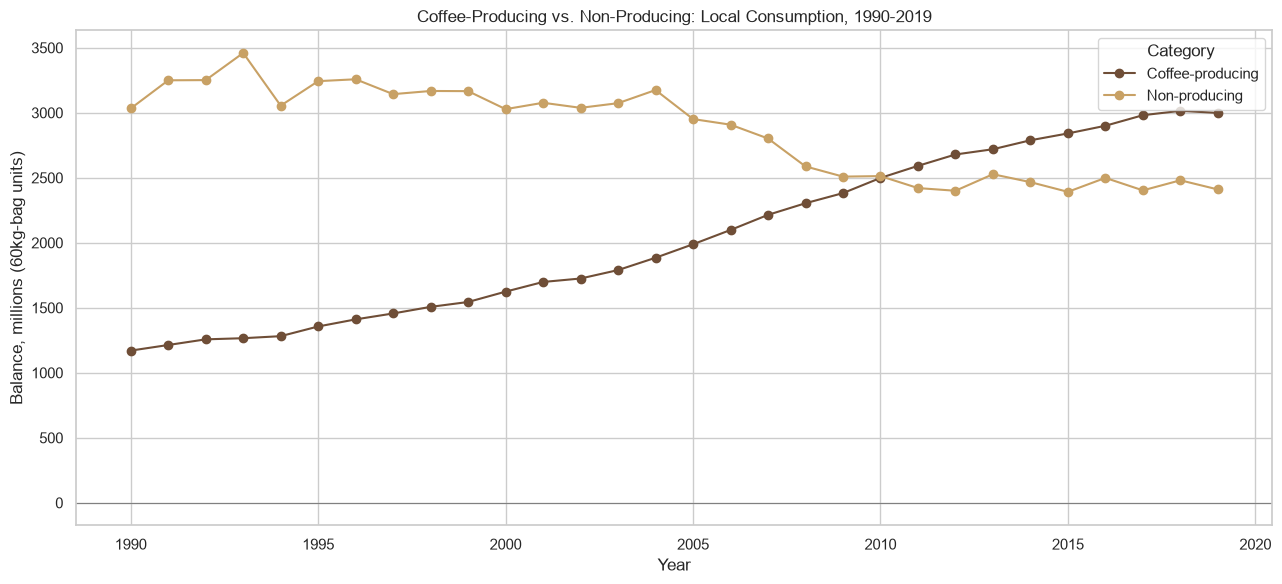

In [23]:
balance_full = (
    balance_df.groupby(["year", "category"])["balance"].sum().unstack("category") / 1e6
)

fig, ax = plt.subplots(figsize=(13, 6))
balance_full.plot(ax=ax, marker="o", color=["#6f4e37", "#c8a165"])
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Coffee-Producing vs. Non-Producing: Local Consumption, 1990-2019")
ax.set_ylabel("Balance, millions (60kg-bag units)")
ax.set_xlabel("Year")
ax.legend(title="Category")
plt.tight_layout()
plt.show()

### Q3 — Full time series: Coffee-producing countries' exports vs. Non-producing countries' re-exports
All 30 years (1990-2019), no sampling. `coffee_export` volume from producing
countries (raw beans leaving origin) plotted against `coffee_re_export` volume
from non-producing countries (coffee that was imported, then shipped onward
rather than consumed) — two different outward-flow metrics, compared on the
same timeline.

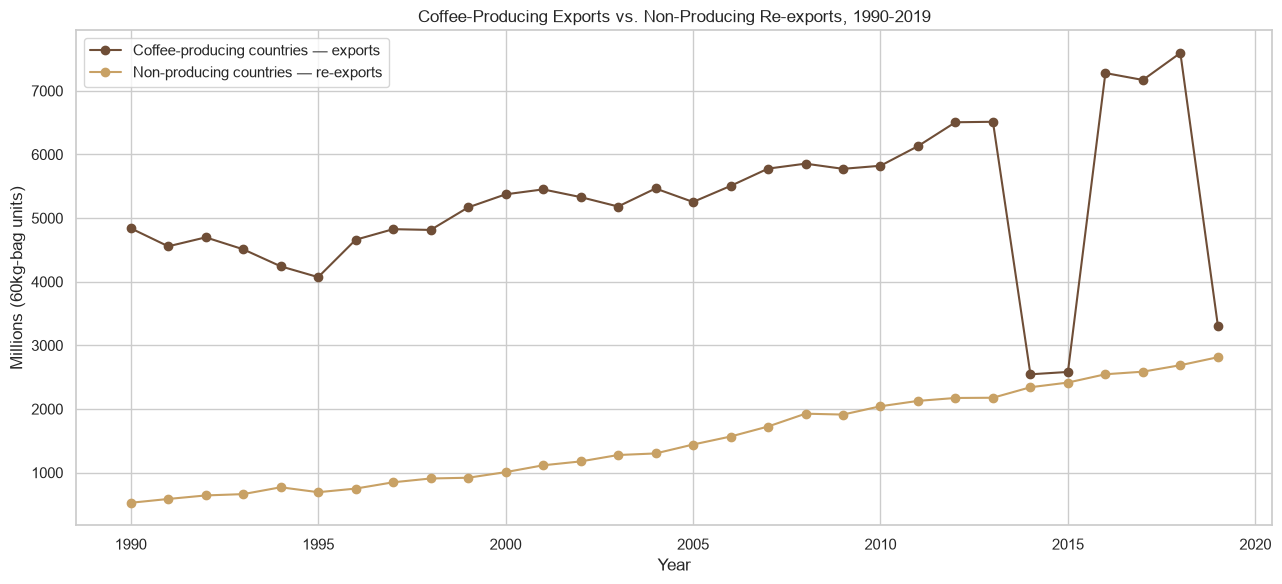

In [24]:
export_prod_long = melt_years(
    df_export[df_export["country_code"].isin(producing_codes)], "export"
)
reexport_nonprod_long = melt_years(
    df_re_export[~df_re_export["country_code"].isin(producing_codes)], "re_export"
)

export_by_year = export_prod_long.groupby("year")["export"].sum() / 1e6
reexport_by_year = reexport_nonprod_long.groupby("year")["re_export"].sum() / 1e6

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(export_by_year.index, export_by_year.values, marker="o",
        label="Coffee-producing countries — exports", color="#6f4e37")
ax.plot(reexport_by_year.index, reexport_by_year.values, marker="o",
        label="Non-producing countries — re-exports", color="#c8a165")

ax.set_title("Coffee-Producing Exports vs. Non-Producing Re-exports, 1990-2019")
ax.set_xlabel("Year")
ax.set_ylabel("Millions (60kg-bag units)")
ax.legend()
plt.tight_layout()
plt.show()

### Q5 — Full time series: three-way comparison
All 30 years (1990-2019), no sampling. Three lines on one chart:
1. **Coffee-producing — consumed locally** (`coffee_domestic_consumption`, no
   re-export data exists for producers, so this equals their full consumption)
2. **Non-producing — consumed locally** (`coffee_importers_consumption` minus
   `coffee_re_export`)
3. **Non-producing — re-exported** (`coffee_re_export`)

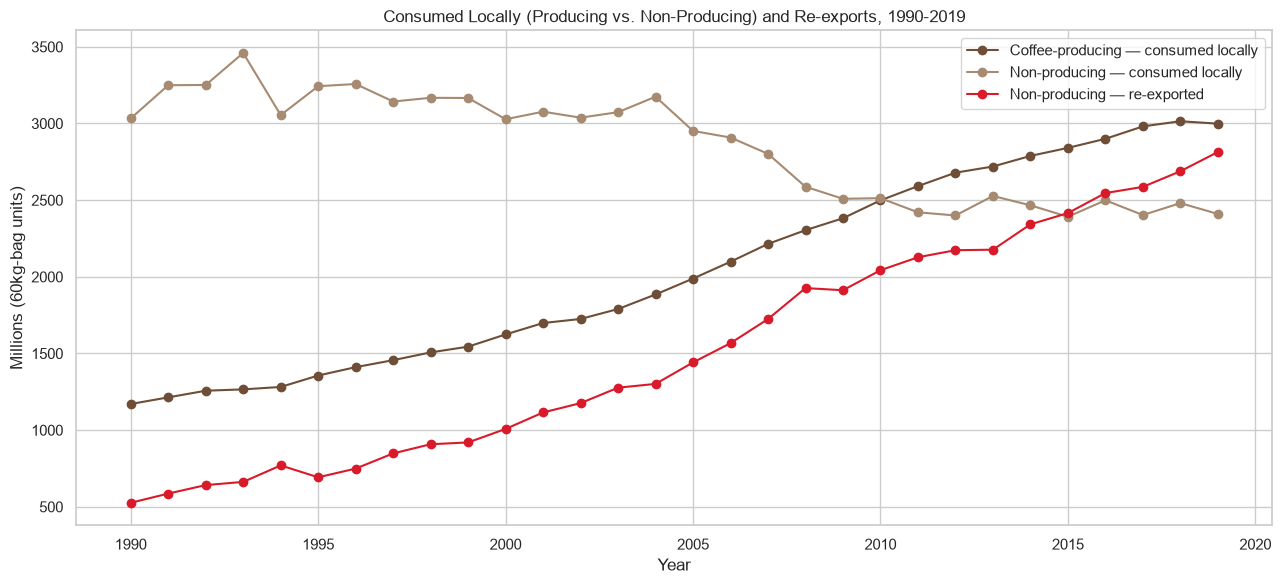

In [25]:
prod_local_by_year = (
    melt_years(df_domestic_consumption[df_domestic_consumption["country_code"].isin(producing_codes)],
               "consumption")
    .groupby("year")["consumption"].sum() / 1e6
)

nonprod_consumption_by_year = (
    melt_years(df_importers_consumption[~df_importers_consumption["country_code"].isin(producing_codes)],
               "consumption")
    .groupby("year")["consumption"].sum()
)
nonprod_reexport_by_year = (
    melt_years(df_re_export[~df_re_export["country_code"].isin(producing_codes)], "re_export")
    .groupby("year")["re_export"].sum()
)
nonprod_local_by_year = (nonprod_consumption_by_year - nonprod_reexport_by_year) / 1e6
nonprod_reexport_by_year = nonprod_reexport_by_year / 1e6

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(prod_local_by_year.index, prod_local_by_year.values, marker="o",
        label="Coffee-producing — consumed locally", color="#6f4e37")
ax.plot(nonprod_local_by_year.index, nonprod_local_by_year.values, marker="o",
        label="Non-producing — consumed locally", color="#a68a72")
ax.plot(nonprod_reexport_by_year.index, nonprod_reexport_by_year.values, marker="o",
        label="Non-producing — re-exported", color="#d91a2a")
        #label="Non-producing — re-exported", color="#c8a165")

ax.set_title("Consumed Locally (Producing vs. Non-Producing) and Re-exports, 1990-2019")
ax.set_xlabel("Year")
ax.set_ylabel("Millions (60kg-bag units)")
ax.legend()
plt.tight_layout()
plt.show()